# UDFPS PINN Platform — Project Overview

## North Star (v6 Section 1.1)
> **PINN 기반의 역설계 자동화 플랫폼**
>
> - **PINN**: 순수 Physics-Informed Neural Network (힌트 주입 없음)
> - **역설계**: 목표 성능 → 설계변수 역추출
> - **자동화**: 사람 개입 없이 end-to-end
> - **플랫폼**: 재사용 가능한 시스템

---

### 이 노트북의 구성

| # | Section | v6 Reference |
|---|---------|-------------|
| 1 | Physical Stack Structure | Section 2 |
| 2 | Pipeline Architecture | Section 3 |
| 3 | End-to-End Data Flow | Section 3, 10 |
| 4 | PINN Network Architecture | Section 5 |
| 5 | Loss Functions & Curriculum | Section 6, 7 |
| 6 | Design Variable Space | Section 2.5 |
| 7 | PINN Domain with BM Geometry | Section 4 |
| 8 | Project Structure | Section 11.5 |

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Cannot find project root')

PROJECT_ROOT = _find_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
%matplotlib inline

from notebooks.helpers.visualization import (
    plot_full_stack, plot_pipeline, plot_pinn_domain,
    plot_pinn_architecture, plot_loss_and_curriculum,
    plot_data_flow, plot_design_space, plot_project_structure,
)

print(f'UDFPS PINN Platform — {PROJECT_ROOT.name}')

UDFPS PINN Platform — AI_PINN_PROJECT_v03


---
## 1. Physical Stack Structure

v6 Section 2: UDFPS COE (Chip-On-Everything) 스택

빛이 **지문(Finger)** 에서 출발하여 아래로 내려가며 각 레이어를 통과합니다.
각 레이어는 담당하는 **계산 모듈** (TMM / ASM / PINN)이 다릅니다.

| Layer | Thickness | z Range | Module | Key |
|-------|-----------|---------|--------|-----|
| AR Coating | ~300 nm | 590~590.3 | **TMM** | Gorilla DX 4층 |
| Cover Glass | 550 μm | 40~590 | **ASM** | n=1.52, FFT 전파 |
| BM2 | ~0 | z=40 | **PINN** (L_BC, L_phase) | Aperture w₂ |
| ILD | 20 μm | 20~40 | **PINN** (L_H) | 회절 전파 |
| BM1 | ~0 | z=20 | **PINN** (L_BC) | Aperture w₁ |
| Encap | 20 μm | 0~20 | **PINN** (L_H) | 최종 전파 |
| OPD Sensor | - | z=0 | PSF | Photodiode |

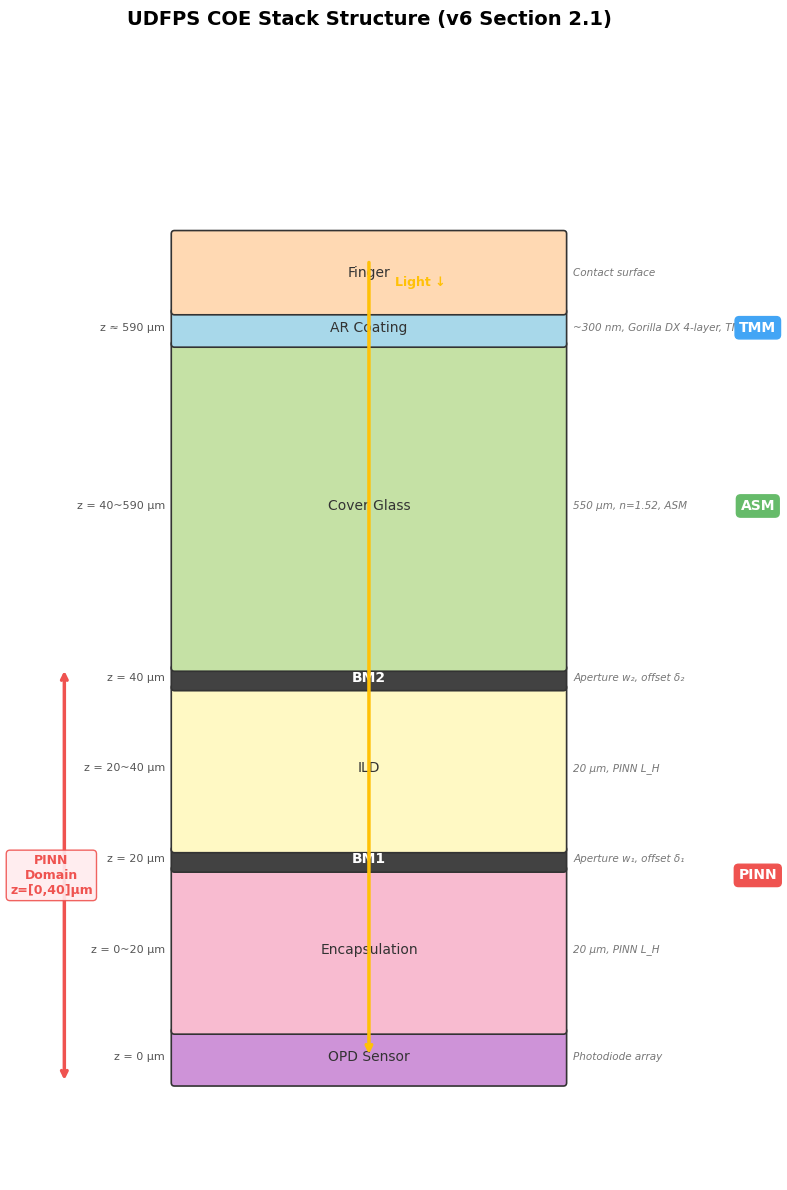

In [2]:
fig, ax = plot_full_stack(figsize=(10, 12))
plt.show()

---
## 2. Pipeline Architecture

v6 Section 3: 하이브리드 파이프라인

각 물리 영역에 맞는 최적의 계산 방법을 사용합니다:

- **TMM**: 박막 이론으로 AR 코팅의 투과/위상 계산 (정확, 해석적)
- **ASM**: FFT 기반 자유공간 전파로 CG 통과 (빠름, 설계변수 무관)
- **PINN**: BM 회절 + 위상 왜곡 결합 학습 (핵심, 설계변수 의존)
- **PSF**: 복소장 → 7개 OPD 픽셀 강도 적분

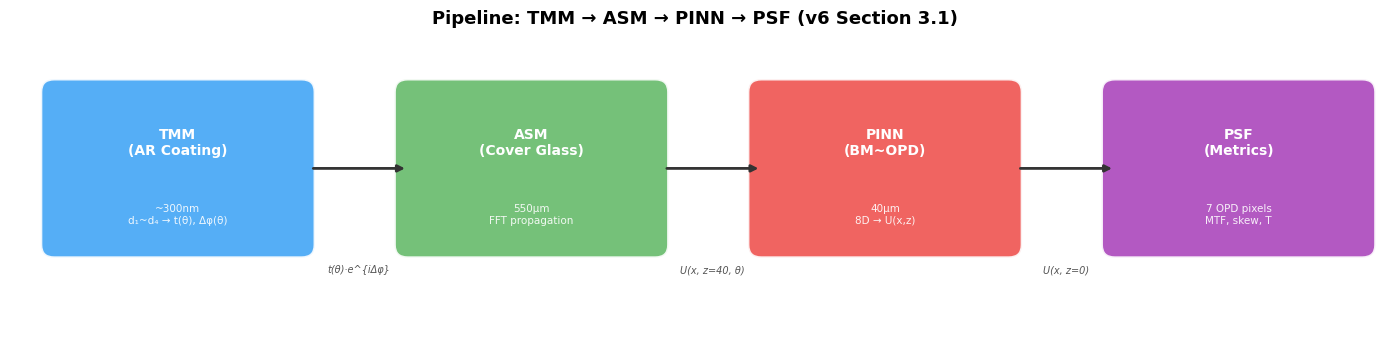

In [3]:
fig, ax = plot_pipeline(figsize=(14, 3.5))
plt.show()

---
## 3. End-to-End Data Flow

v6 Section 3, 10: 전체 시스템이 어떻게 연결되는지 보여줍니다.

**Phase C** (현재): Forward pipeline + PINN 학습
- 설계변수 → TMM → ASM → PINN → PSF → Metrics
- ASM LUT + Collocation → Loss → Optimizer → PINN 업데이트

**Phase D-E** (미래): 역설계 + 배포
- PINN → FNO 증류 → BoTorch 최적화 → Design Studio UI

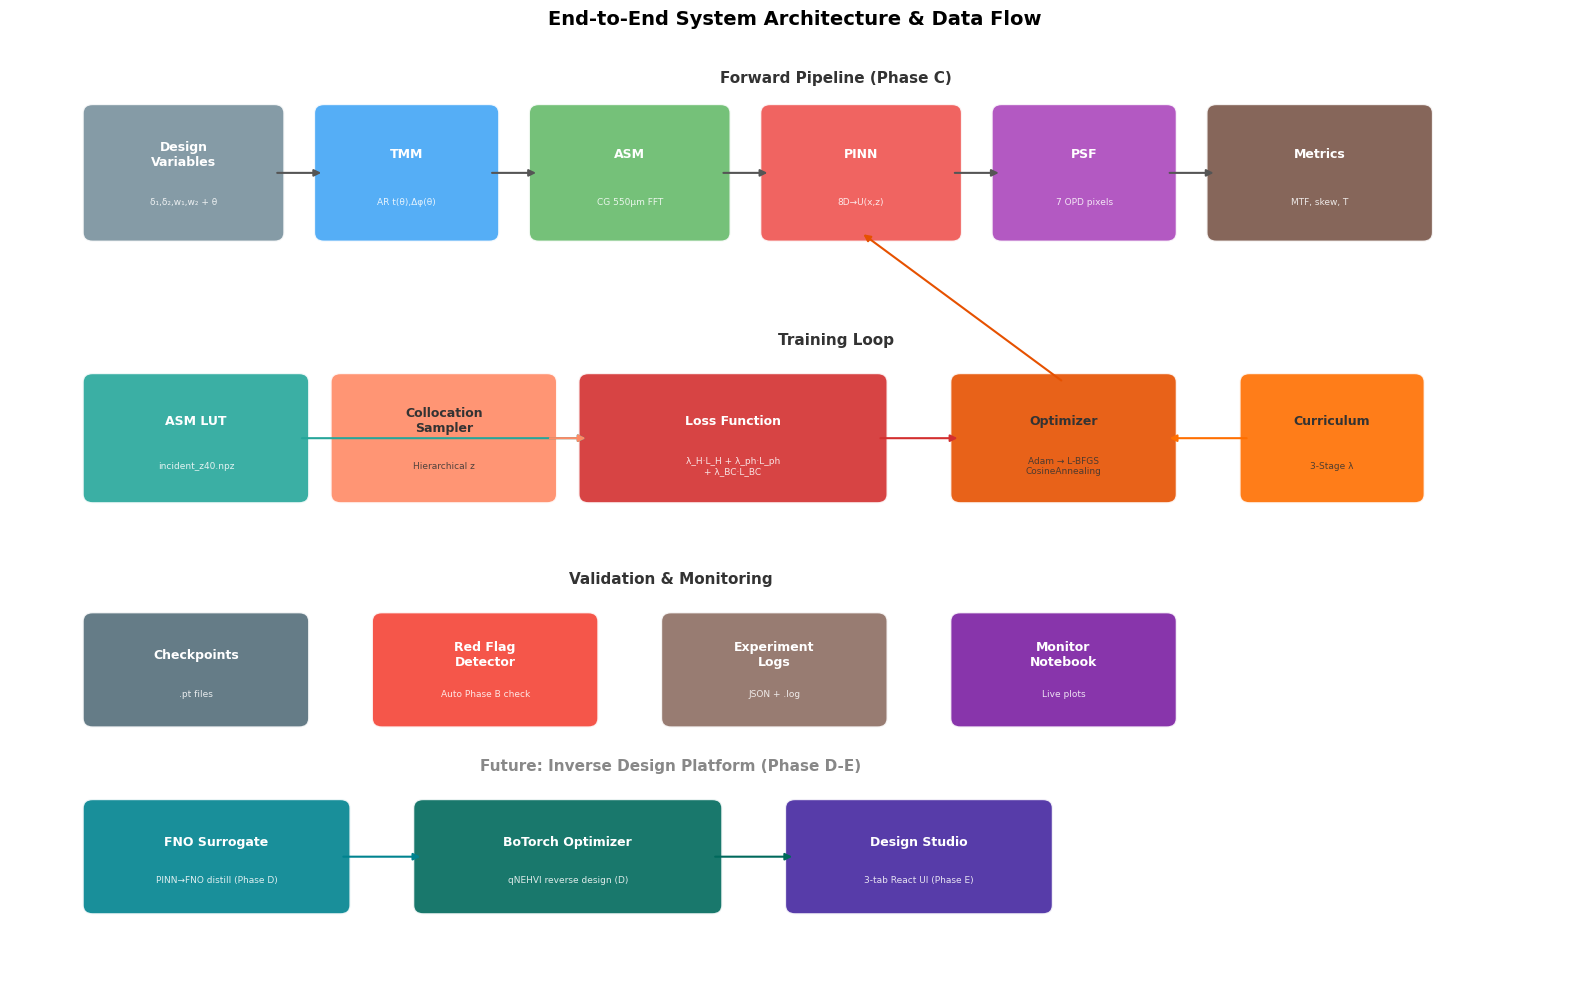

In [4]:
fig, ax = plot_data_flow(figsize=(16, 10))
plt.show()

---
## 4. PINN Network Architecture

v6 Section 5: Pure PINN (8D 입력, SIREN + Fourier Feature)

**핵심 원칙** (v6 🛑 금지사항):
- ❌ Hard mask 금지 — BM=0은 loss(L_BC)로 학습
- ❌ slit_dist 입력 금지 — 입력은 반드시 8D
- ✅ 네트워크가 순수하게 물리를 학습

| Component | Detail |
|-----------|--------|
| Input | 8D: (x, z, δ₁, δ₂, w₁, w₂, sinθ, cosθ) |
| Normalization | x/504, z/40, δ/10, (w-12.5)/7.5 |
| Fourier Embedding | 48 random frequencies → 96 features |
| Hidden Layers | 4 × SIREN (128-dim, ω₀=30) |
| Output | 2D: (Re(U), Im(U)) |
| Parameters | ~100K |

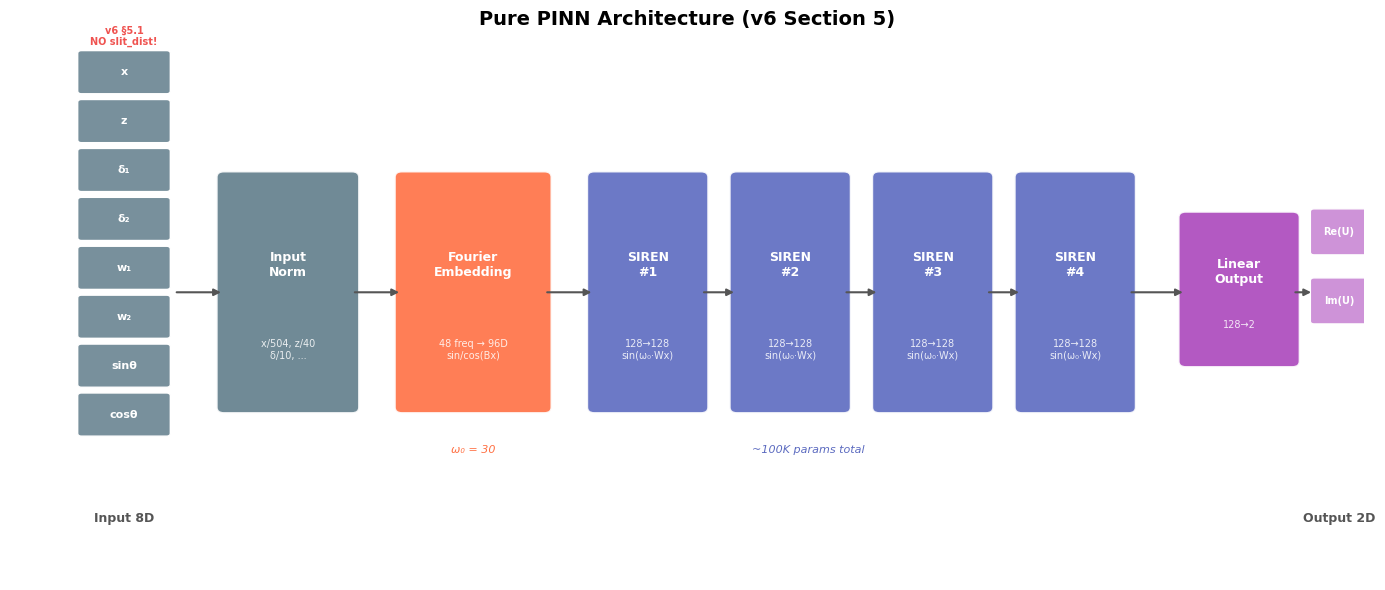

In [5]:
fig, ax = plot_pinn_architecture(figsize=(14, 6))
plt.show()

---
## 5. Loss Functions & Curriculum

v6 Section 6, 7: 4가지 Loss + 3단계 커리큘럼

### Loss 구성 규칙
```
L_total = λ_H · L_Helmholtz + λ_phase · L_phase + λ_BC · L_BC + λ_I · L_I

λ_H = 1.0 (주 학습 신호)
λ_phase = 0.5, λ_BC = 0.5, λ_I = 0.3
Rule: λ_H ≥ max(λ_phase, λ_BC, λ_I)
```

### Curriculum 3-Stage
- **Stage 1** (0~20%): 경계조건만 학습 (L_phase + L_BC)
- **Stage 2** (20~60%): PDE 활성화 (L_H ramp 0.1→1.0)
- **Stage 3** (60~100%): 전체 loss 학습

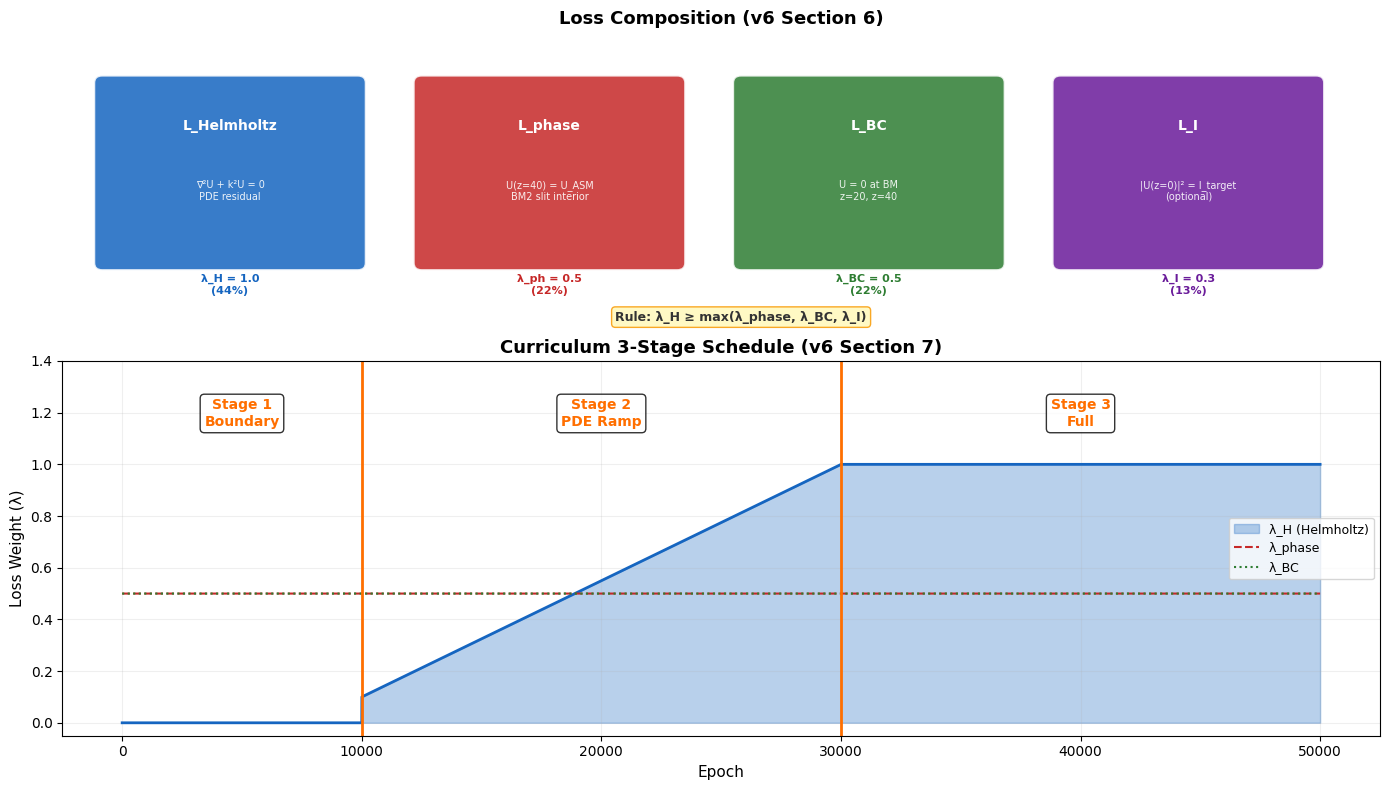

In [6]:
fig, axes = plot_loss_and_curriculum(total_epochs=50000, figsize=(14, 8))
plt.show()

---
## 6. Design Variable Space

v6 Section 2.5: Phase C에서 최적화하는 4개 설계변수

PINN은 이 4D 공간 전체에서 **파라메트릭**하게 학습합니다:
- 임의의 (δ₁, δ₂, w₁, w₂) 조합에 대해 U(x,z) 예측 가능
- Phase D에서 AR 두께 4개 추가 → 8D 확장

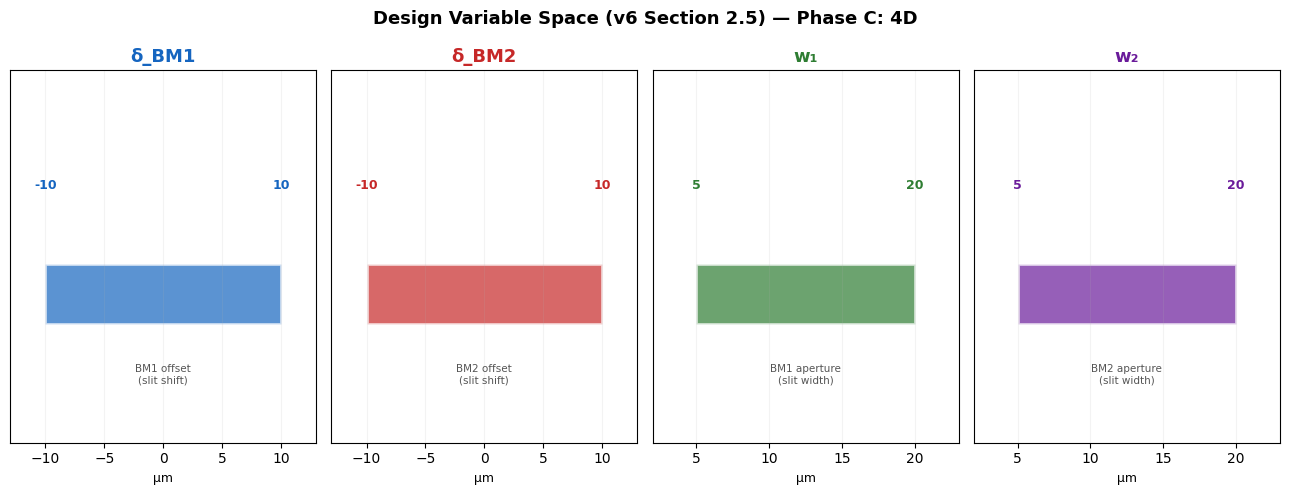

In [7]:
fig, axes = plot_design_space(figsize=(13, 5))
plt.show()

---
## 7. PINN Domain with BM Geometry

v6 Section 2.3, 4: PINN이 학습하는 물리 도메인

- **x**: 0~504 μm (7 OPD pitches × 72 μm)
- **z**: 0~40 μm (OPD → BM2)
- **BM** (검정): 불투명 영역, U=0 (L_BC)
- **Slit** (흰색): 빛이 통과하는 아퍼처

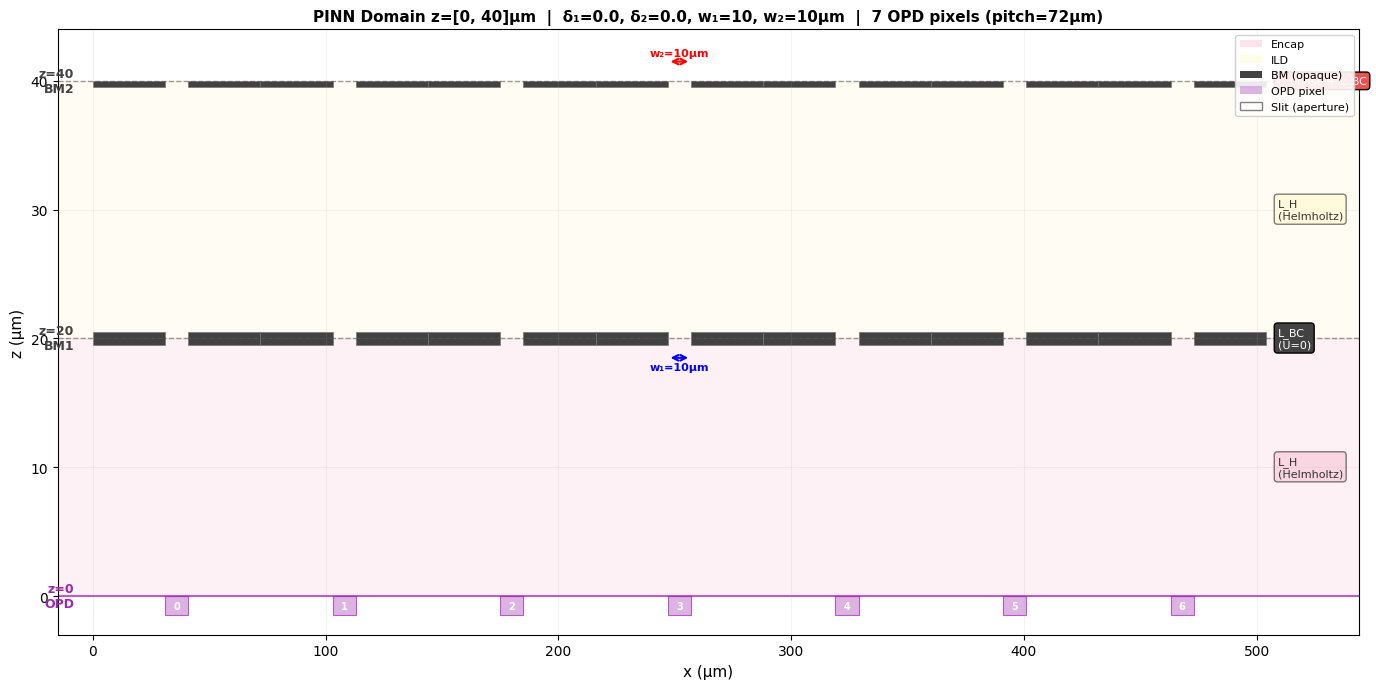

In [8]:
fig, ax = plot_pinn_domain(
    delta_bm1=0, delta_bm2=0, w1=10, w2=10,
    figsize=(14, 7)
)
plt.show()

### 설계변수 변화 예시: 비대칭 BM 구조

δ₁=5 (BM1 오른쪽 이동), δ₂=-5 (BM2 왼쪽 이동), w₁=8, w₂=15

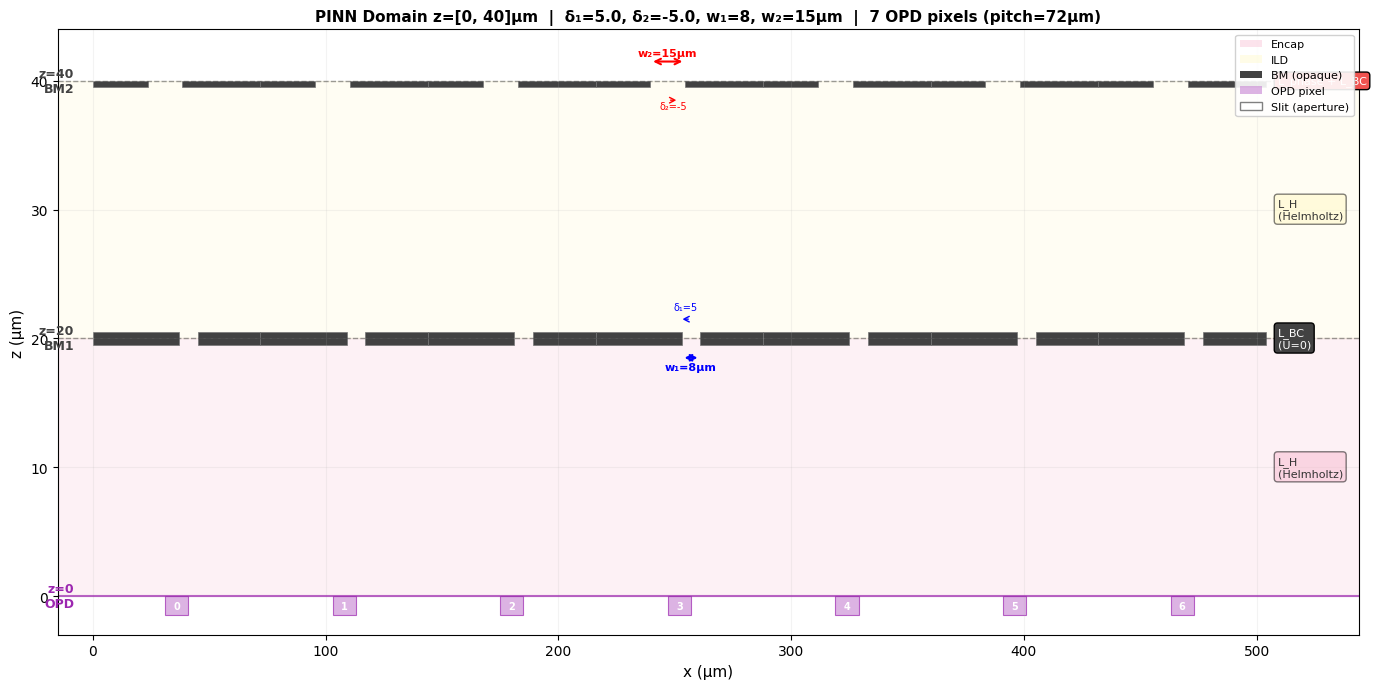

In [9]:
fig, ax = plot_pinn_domain(
    delta_bm1=5, delta_bm2=-5, w1=8, w2=15,
    figsize=(14, 7)
)
plt.show()

---
## 8. Project Structure

v6 Section 11.5: 하이브리드 3-Layer 개발 패턴

```
[Layer 1] notebooks/  →  실험/탐색/분석 (Jupyter)
         ↓ 확정된 로직 추출
[Layer 2] backend/    →  재사용 모듈 (Python)
         ↓ CLI/API 감싸기
[Layer 3] scripts/api/ →  실행/배포 (CLI, FastAPI)
```

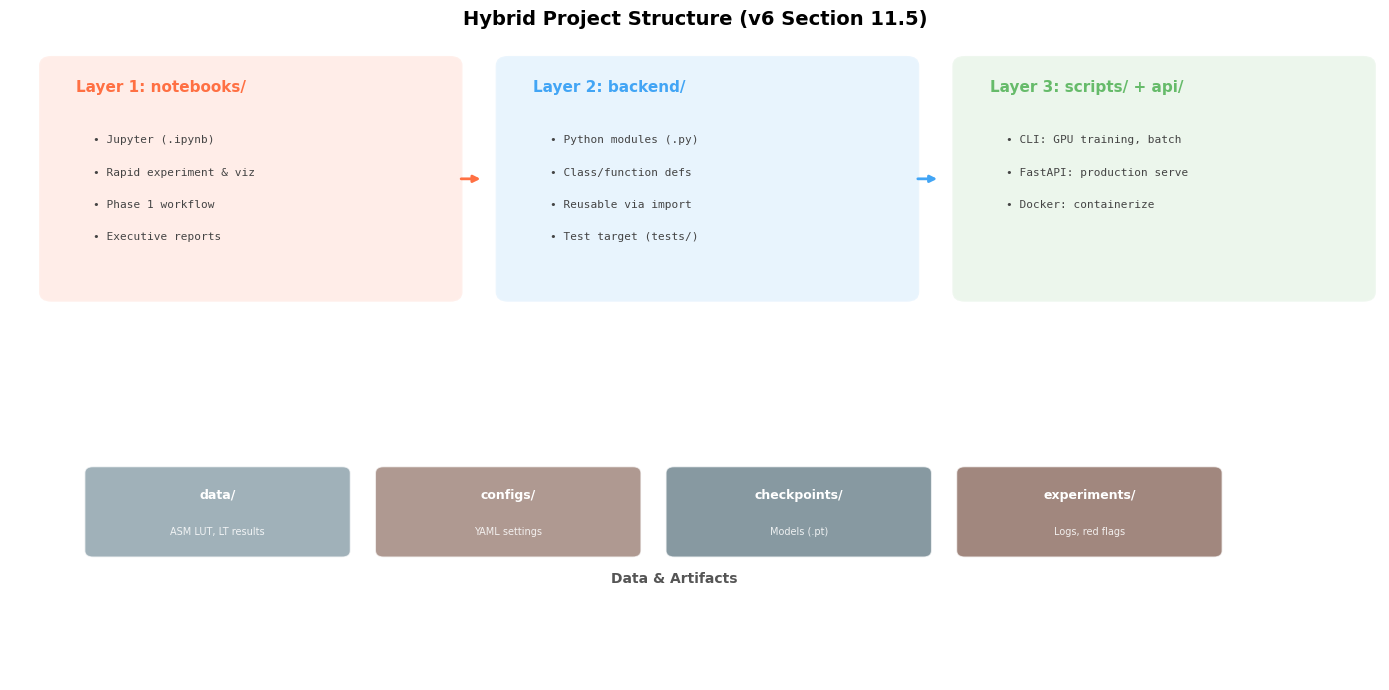

In [10]:
fig, ax = plot_project_structure(figsize=(14, 7))
plt.show()

---
## Phase Roadmap

| Phase | Goal | Status |
|-------|------|--------|
| **Phase 1** | TMM+ASM+BO 파일럿 | ✅ 완료 (MTF 99.78%) |
| **Phase B** | PINN 첫 시도 | ❌ 실패 (우회 기법) |
| **Phase C** | Pure PINN 정석 구현 | 🔄 **진행 중** |
| Phase D | FNO 증류 + BoTorch 역설계 | ⬜ 대기 |
| Phase E | Design Studio + FastAPI 배포 | ⬜ 대기 |

---

### Next Steps
1. `notebooks/02_phase_c_development/02_pinn_cpu_validation.ipynb` — CPU 구조 검증
2. `scripts/train_phase_c.py` — GPU 본 학습
3. `notebooks/02_phase_c_development/03_pinn_training_monitor.ipynb` — 학습 모니터링